In [1]:
# Librosa -> Audio and music analysis
# torch audio: Library for audio and signal processing
!pip install librosa
!pip install torchaudio
!pip install torch
!pip install matplotlib
!pip install scikit-learn

In [2]:
import os
import torch
import random
import librosa
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE


In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [4]:
df=pd.read_csv('/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/metadata_handover.csv')

In [5]:
df.head(20)

,file_id,label,source,age,gender
0,asthma_v2_Bronchial_P21BronchialTc_101.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
1,asthma_v2_Bronchial_P17BronchialTc_81.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
2,asthma_v2_Bronchial_P21BronchialSc_104.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
3,asthma_v2_Bronchial_P9BronchialTc_43.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
4,asthma_v2_Bronchial_P5BronchialTc_25.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
5,asthma_v2_Bronchial_P12BronchialTc_57.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
6,asthma_v2_Bronchial_P8BronchialTc_39.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
7,asthma_v2_Bronchial_P11BronchialSc_54.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
8,asthma_v2_Bronchial_P4BronchialTc_19.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN
9,asthma_v2_Bronchial_P3BronchialTc_15.wav,Bronchitis,Asthma_V2_Smartphone,NaN,NaN


In [6]:
files=[]

df.drop(columns=['age','gender'],axis=1,inplace=True)

In [7]:
df.tail()

,file_id,label,source
1206,asthma_v2_copd_P11COPDPr_83.wav,copd,Asthma_V2_Smartphone
1207,asthma_v2_copd_P18COPDPr_139.wav,copd,Asthma_V2_Smartphone
1208,asthma_v2_copd_P35COPDMc_276.wav,copd,Asthma_V2_Smartphone
1209,asthma_v2_copd_P3COPDMc_22.wav,copd,Asthma_V2_Smartphone
1210,asthma_v2_copd_P24COPDMc_192.wav,copd,Asthma_V2_Smartphone


(13, 188)


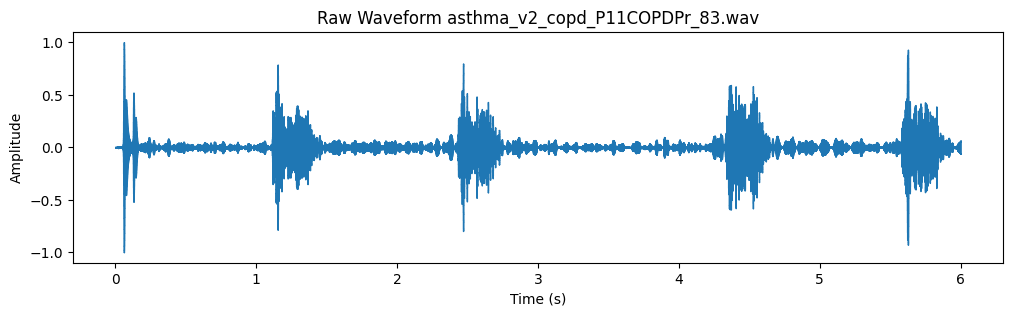

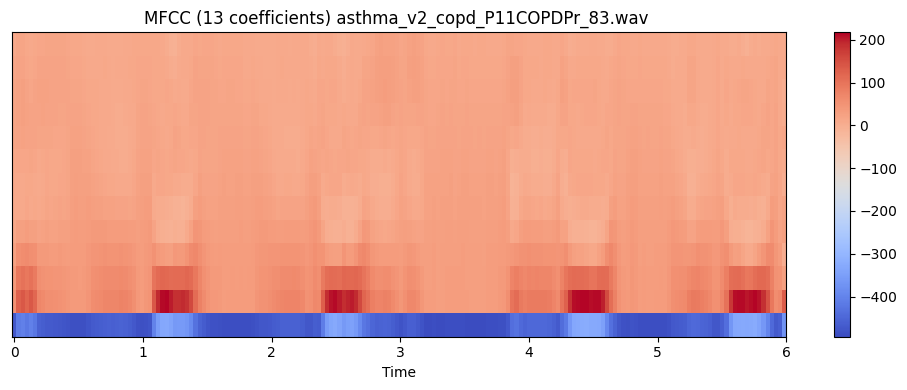

(13, 188)


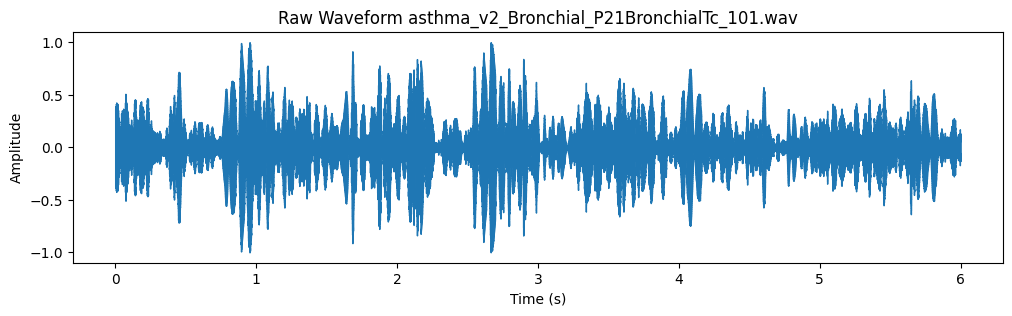

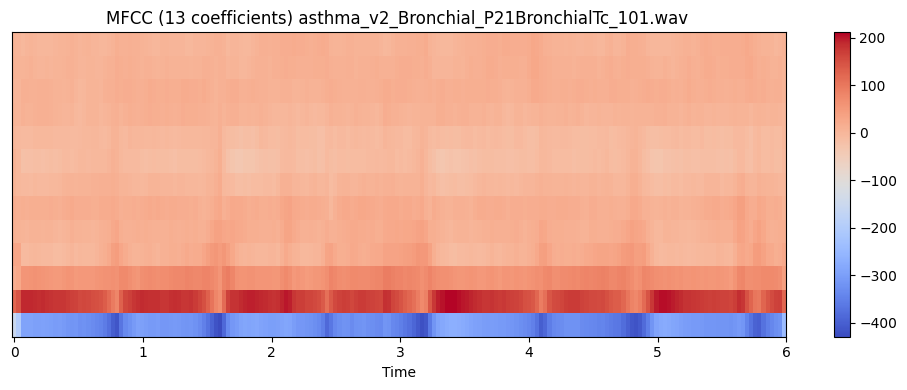

(13, 188)


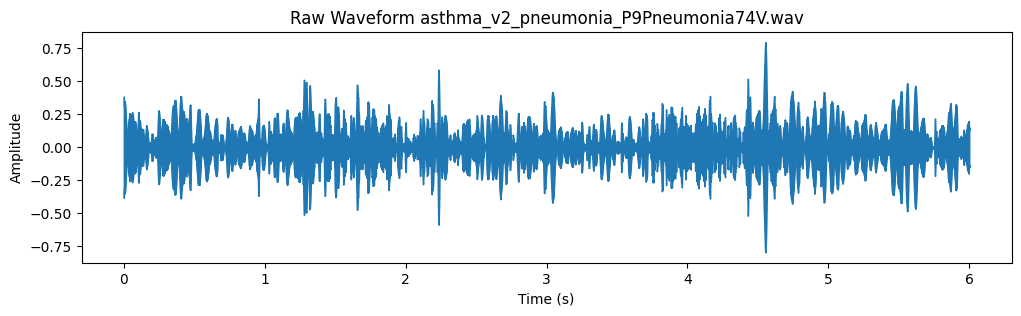

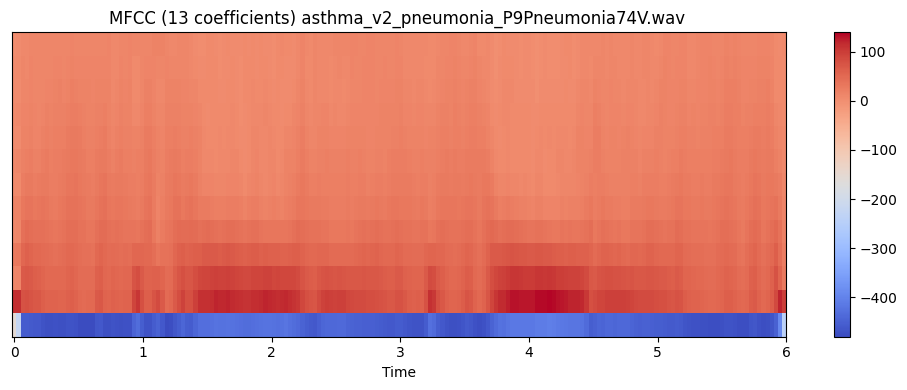

(13, 188)


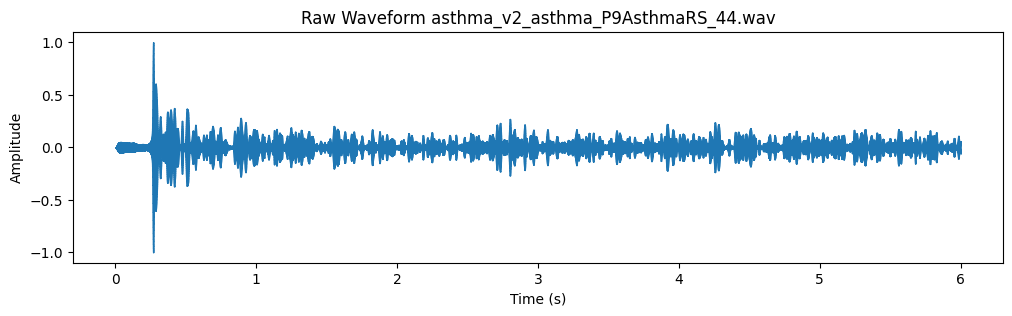

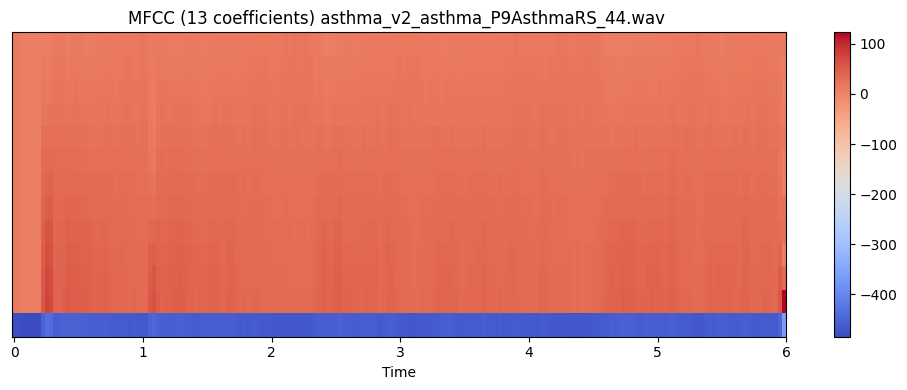

(13, 188)


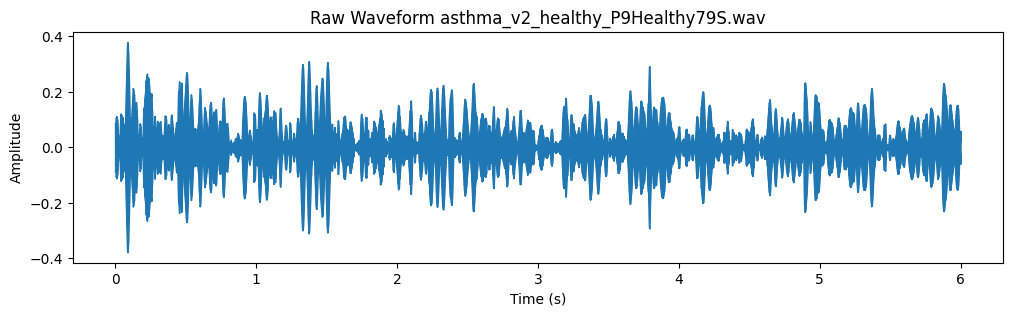

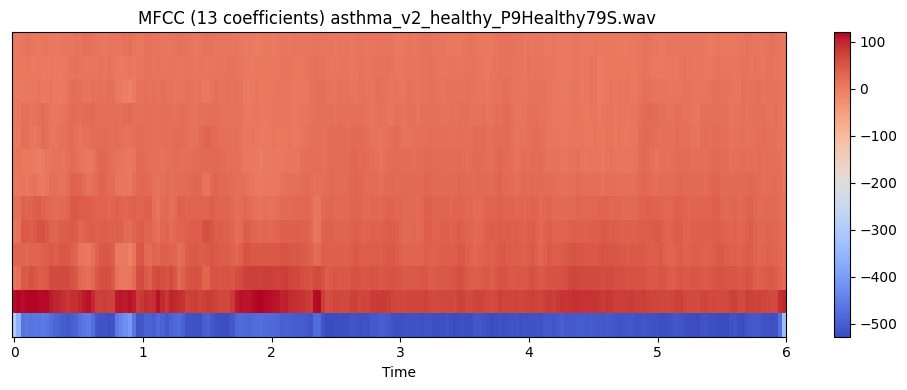

In [8]:
base_path='/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/audio_files'
sample_files=['asthma_v2_copd_P11COPDPr_83.wav','asthma_v2_Bronchial_P21BronchialTc_101.wav','asthma_v2_pneumonia_P9Pneumonia74V.wav','asthma_v2_asthma_P9AsthmaRS_44.wav','asthma_v2_healthy_P9Healthy79S.wav']
for file in sample_files:
    sample_path=f'{base_path}/{file}'
    wave_form,sample_rate=librosa.load(sample_path,sr=16000)
    
    mfcc=librosa.feature.mfcc(
    y=wave_form,
    sr=sample_rate,
    n_mfcc=13)

    print(mfcc.shape)
    plt.figure(figsize=(12, 3))
    
    librosa.display.waveshow(wave_form, sr=16000)
    plt.title(f"Raw Waveform {file}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=16000)
    plt.colorbar()
    plt.title(f"MFCC (13 coefficients) {file} ")
    plt.tight_layout()
    plt.show()
    



MFCC (Mel-Frequency Cepstral Coefficients)
- Compresses the audio into meaningful frequency features
- Captures quality of tone and texture distinguishing different cough sounds

In [9]:
# load and resample to 16Khz
# waveform->1D array of amplitude values
# Sample rate->16000

In [10]:
print(wave_form.shape)
print(sample_rate)

(96000,)
16000


In [11]:
# Distrbution check
class_count = df["label"].value_counts()
class_percent=df['label'].value_counts(normalize=True)*100
print(class_count)
print("\n Class percent")
print(class_percent)

label
copd          401
asthma        288
pneumonia     285
healthy       133
Bronchitis    104
Name: count, dtype: int64

 Class percent
label
copd          33.113130
asthma        23.781998
pneumonia     23.534269
healthy       10.982659
Bronchitis     8.587944
Name: proportion, dtype: float64


In [12]:
class_counts=df['label'].value_counts()

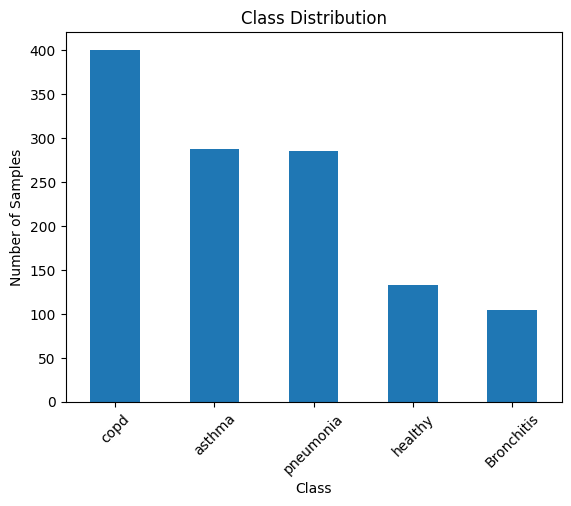

In [13]:

class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Label standadization
df['label']=df['label'].str.lower()


In [15]:
 df["label"].value_counts()

label
copd          401
asthma        288
pneumonia     285
healthy       133
bronchitis    104
Name: count, dtype: int64

In [16]:
# Energy silence ratio check
def compute_silence_ratio(file_path, threshold=0.01, sr=16000):
    waveform, _ = librosa.load(file_path, sr=sr)
    amplitude = np.abs(waveform)
    silent_samples = np.sum(amplitude < threshold)
    return silent_samples / len(waveform)

In [17]:
mfcc=librosa.feature.mfcc(
    y=wave_form,
    sr=sample_rate,
    n_mfcc=13
)

print(mfcc.shape)

(13, 188)


13 first coefficients and 188 frames(depends on audio length-> longer audio has larger frames, hop length-> how much the window moves forward each step and sampling rate) Thus need for averagin when creating features for model. 

Use of mean captures overal spectral shape for mfcc and average loudness for rms. Standard deviation captures energy variations for rms and spectral changes for mfcc enabling complete picture of amplitude and capturing of both static and dynamic aspects of the audio signal.

In [18]:
# Convert MFCC to a fixed vector length
mfcc_mean = np.mean(mfcc, axis=1)
mfcc_std = np.std(mfcc, axis=1)

feature_vector = np.concatenate([mfcc_mean, mfcc_std])

print(feature_vector.shape)

(26,)


In [19]:
def pad_audio(waveform,sr,min_duration=1.5):
    """Pad short audio files with 0 ensuring uniform length"""
    target_size=int(sr* min_duration)
    if(len(waveform)<target_size):
        waveform=np.pad(y,(0,target_size-len(y)))
    return y

In [20]:
# Data Augmentation
def pitch_shift_augment(waveform, sr=16000, n_steps_range=(-2, 2)):
    """Shift pitch without changing duration"""
    n_steps = np.random.randint(n_steps_range[0], n_steps_range[1])
    return librosa.effects.pitch_shift(waveform, sr=sr, n_steps=n_steps)

def time_stretch_augment(waveform, rate_range=(0.9, 1.1)):
    """Stretch/compress audio duration"""
    rate = np.random.uniform(rate_range[0], rate_range[1])
    return librosa.effects.time_stretch(waveform, rate=rate)

def add_background_noise(waveform, noise_factor=0.005):
    """Add random Gaussian noise to simulate environmental noise"""
    noise = np.random.normal(0, 1, len(waveform)) * noise_factor
    return waveform + noise
    
def add_white_noise(waveform, snr_db=20):
    """Add white noise with specific SNR"""
    power = np.mean(waveform ** 2)
    noise_power = power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(waveform))
    return waveform + noise

In [21]:
# Augmented features
def preprocess_audio_augmented(waveform, target_sr=16000, n_mfcc=13, apply_augment=True):
    """
    Preprocesses audio with optional augmentation.
    Augmentation happens on waveform BEFORE feature extraction.
    """
    y = pad_audio(waveform, target_sr)
    
    # Apply augmentation on waveform (before feature extraction)
    if apply_augment:
        
        if np.random.random() > 0.3:
            y = add_background_noise(y, noise_factor=0.003)
        
        # if np.random.random() > 0.4:
        #     y = add_white_noise(y, snr_db=25)
        
        if np.random.random() > 0.5:
            y = pitch_shift_augment(y, n_steps_range=(-1, 1))
        
        if np.random.random() > 0.5:
            y = time_stretch_augment(y, rate_range=(0.95, 1.05))
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=target_sr,
        n_mfcc=n_mfcc
    )
    
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)
    rms_std = np.std(rms)
    rms_mean = np.array([rms_mean])
    rms_std = np.array([rms_std])
    
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.array([np.mean(zcr)])
    zcr_std = np.array([np.std(zcr)])
    
    feature_vector = np.concatenate([mfcc_mean, mfcc_std, rms_mean, rms_std, zcr_mean, zcr_std])
    
    return feature_vector

In [22]:

def preprocess_audio(waveform, target_sr=16000, n_mfcc=13):
    """
    Reads an audio file and returns a fixed-length feature vector
    using MFCC mean and standard deviation.
    """
    # waveform, sample_rate = librosa.load(file_path, sr=target_sr)
    
    y=pad_audio(waveform,target_sr)
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=target_sr,
        n_mfcc=n_mfcc
    )
    
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    rms=librosa.feature.rms(y=y)
    rms_mean=np.mean(rms)
    rms_std=np.std(rms)

    rms_mean = np.array([rms_mean])
    rms_std = np.array([rms_std])

    zcr=librosa.feature.zero_crossing_rate(y)
    zcr_mean=np.array([np.mean(zcr)])
    zcr_std=np.array([np.std(zcr)])
    
    
    # Combine into single feature vector
    feature_vector = np.concatenate([mfcc_mean, mfcc_std,rms_mean,rms_std,zcr_mean,zcr_std])
    
    return feature_vector

In [23]:
audio_data = {}  

for _, row in df.iterrows():
    file_path = os.path.join(base_path, row['file_id'])
    
    if os.path.exists(file_path):
        y, sr = librosa.load(file_path, sr=16000)
        audio_data[row['file_id']] = {'waveform': y, 'sr': sr}
    else:
        print("Missing file:", file_path)

In [24]:
silence_ratios = []
durations = []

for _, row in df.iterrows():
    file_id = row['file_id']
    if file_id in audio_data:
        y = audio_data[file_id]['waveform']
        sr = audio_data[file_id]['sr']
        
        # Duration
        durations.append(len(y)/sr)
        
        # Silence ratio
        amplitude = abs(y)
        ratio = (amplitude < 0.01).sum() / len(y)
        silence_ratios.append(ratio)
    else:
        durations.append(None)
        silence_ratios.append(None)

df['duration_sec'] = durations
df['silence_ratio'] = silence_ratios

In [25]:
print(ratio)

0.050270833333333334


In [26]:
df.groupby("label")["silence_ratio"].mean()

label
asthma        0.127217
bronchitis    0.272829
copd          0.080554
healthy       0.110424
pneumonia     0.077252
Name: silence_ratio, dtype: float64

In [27]:
df.groupby("label")["silence_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
asthma,288.0,0.127217,0.107096,0.011154,0.055721,0.096693,0.141187,0.452906
bronchitis,104.0,0.272829,0.240442,0.021146,0.063435,0.146042,0.515049,0.783635
copd,401.0,0.080554,0.085621,0.011062,0.030695,0.046698,0.087292,0.572854
healthy,133.0,0.110424,0.084325,0.015250,0.043771,0.075510,0.154792,0.338292
pneumonia,285.0,0.077252,0.065881,0.013594,0.033635,0.044427,0.106865,0.322667


In [28]:
df.groupby("label")["duration_sec"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
asthma,288.0,5.865391,0.661399,0.480000,6.0,6.0,6.0,6.0
bronchitis,104.0,5.860596,0.678941,2.000062,6.0,6.0,6.0,6.0
copd,401.0,5.985406,0.086716,4.944000,6.0,6.0,6.0,6.0
healthy,133.0,5.915033,0.249460,4.617438,6.0,6.0,6.0,6.0
pneumonia,285.0,5.865570,0.380365,3.072000,6.0,6.0,6.0,6.0


In [29]:
df['duration_sec'].describe()

count    1211.000000
mean        5.910214
std         0.435046
min         0.480000
25%         6.000000
50%         6.000000
75%         6.000000
max         6.000000
Name: duration_sec, dtype: float64

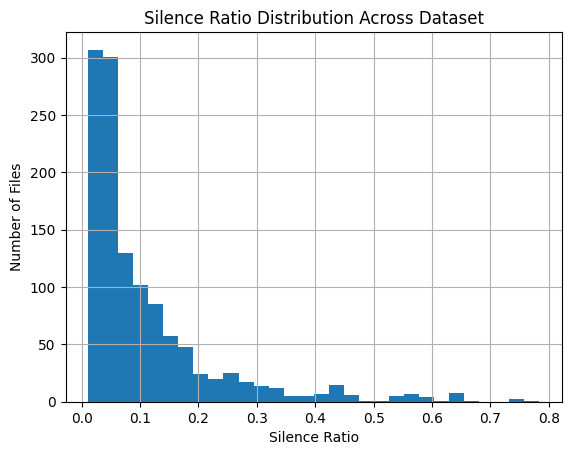

In [30]:

df["silence_ratio"].hist(bins=30)
plt.xlabel("Silence Ratio")
plt.ylabel("Number of Files")
plt.title("Silence Ratio Distribution Across Dataset")
plt.show()

In [31]:
X = []
y_labels = []

for _, row in df.iterrows():
    file_id = row['file_id']
    label = row['label']
    
    if file_id in audio_data:
        y = audio_data[file_id]['waveform']
        sr = audio_data[file_id]['sr']
        
        # features = preprocess_audio(y, sr)
        features=preprocess_audio_augmented(y,sr)
        X.append(features)
        y_labels.append(label)

X = np.array(X)
y = np.array(y_labels)

In [32]:
print(X.shape)
print(y.shape)

(1211, 30)
(1211,)


# Random Forest Classifer

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


In [34]:
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    class_weight="balanced"
)

start_train = time.perf_counter()

model.fit(X_train_balanced, y_train_balanced) 

end_train = time.perf_counter()
training_time = end_train - start_train

start_infer = time.perf_counter()

y_pred = model.predict(X_test)

end_infer = time.perf_counter()
inference_time = end_infer - start_infer

per_sample_time = inference_time / len(X_test)

print(f"Training Time RF: {training_time:.4f} seconds")
print(f"Inference Time RF(total): {inference_time:.6f} seconds")
print(f"Inference Time per sample RF: {per_sample_time:.8f} seconds")

Training Time RF: 1.0283 seconds
Inference Time RF(total): 0.012416 seconds
Inference Time per sample RF: 0.00005110 seconds


In [35]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_balanced))

Before SMOTE: Counter({np.str_('copd'): 321, np.str_('asthma'): 230, np.str_('pneumonia'): 228, np.str_('healthy'): 106, np.str_('bronchitis'): 83})
After SMOTE: Counter({np.str_('copd'): 321, np.str_('bronchitis'): 321, np.str_('asthma'): 230, np.str_('pneumonia'): 228, np.str_('healthy'): 106})


In [36]:
for true, pred in zip(y_test[:10], y_pred[:10]):
    print("True:", true, "| Predicted:", pred)

True: asthma | Predicted: pneumonia
True: copd | Predicted: copd
True: bronchitis | Predicted: bronchitis
True: asthma | Predicted: healthy
True: pneumonia | Predicted: pneumonia
True: healthy | Predicted: pneumonia
True: bronchitis | Predicted: bronchitis
True: asthma | Predicted: asthma
True: bronchitis | Predicted: bronchitis
True: pneumonia | Predicted: pneumonia


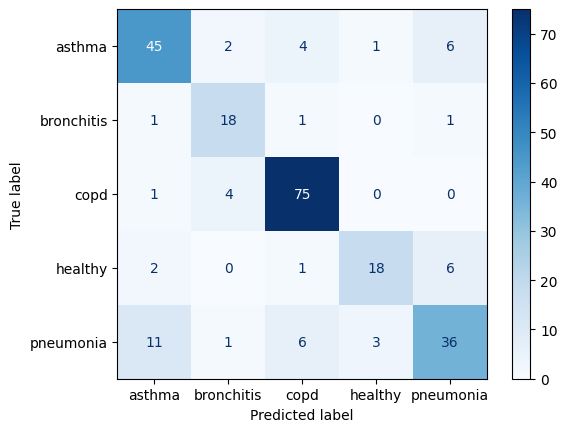

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [38]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

      asthma       0.75      0.78      0.76        58
  bronchitis       0.72      0.86      0.78        21
        copd       0.86      0.94      0.90        80
     healthy       0.82      0.67      0.73        27
   pneumonia       0.73      0.63      0.68        57

    accuracy                           0.79       243
   macro avg       0.78      0.77      0.77       243
weighted avg       0.79      0.79      0.79       243



# SVM Modeling

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [40]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=SEED
    ))
])


start_train = time.perf_counter()

# svm.fit(X_train, y_train)
svm.fit(X_train_balanced,y_train_balanced)

end_train = time.perf_counter()
training_time = end_train - start_train


start_infer = time.perf_counter()

svm_pred = svm.predict(X_test)

end_infer = time.perf_counter()
inference_time = end_infer - start_infer

per_sample_time = inference_time / len(X_test)

print(f"Training Time SVM: {training_time:.4f} seconds")
print(f"Inference Time SVM (total): {inference_time:.6f} seconds")
print(f"Inference Time per sample SVM: {per_sample_time:.8f} seconds")

Training Time SVM: 0.5064 seconds
Inference Time SVM (total): 0.024406 seconds
Inference Time per sample SVM: 0.00010044 seconds


In [41]:
# svm_pred = svm.predict(X_test)
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

      asthma       0.71      0.78      0.74        58
  bronchitis       0.80      0.76      0.78        21
        copd       0.95      0.88      0.91        80
     healthy       0.58      0.93      0.71        27
   pneumonia       0.81      0.61      0.70        57

    accuracy                           0.79       243
   macro avg       0.77      0.79      0.77       243
weighted avg       0.81      0.79      0.79       243



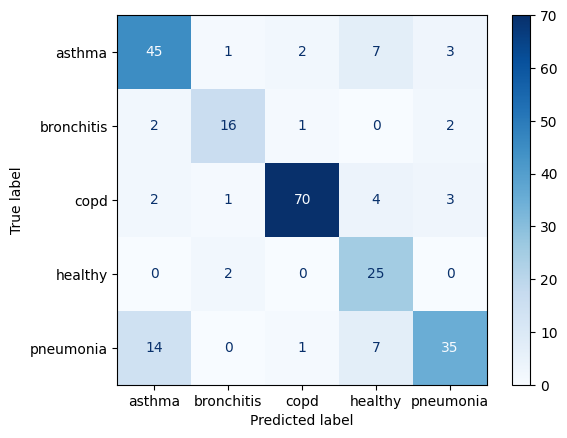

In [42]:
cm = confusion_matrix(y_test, svm_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
disp.plot(cmap=plt.cm.Blues)
plt.show()